# PM2.5 and Weather Relationships - Individual Graphs

Generates individual graphs showing relationships between PM2.5 and weather variables
All times in Japan Standard Time (JST)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import pytz
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## Load Data with Weather Variables

In [2]:
print("Loading PM2.5 enriched dataset with weather data...")
data_path = '/Users/vojtech/Code/Bard89/smoglens-data/pm25_enriched_2023_2025_v4_20250830_222050.csv'

df = pd.read_csv(data_path, 
                 parse_dates=['timestamp'],
                 usecols=['timestamp', 'hex7_id', 'pm25_ugm3_mean', 
                         'temperature_c_mean', 'humidity_pct_mean', 
                         'precipitation_mm_mean', 'pressure_hpa_mean',
                         'dew_point_c_mean', 'avg_traffic_volume',
                         'cloud_cover_pct_mean', 'solar_radiation_wm2_mean'])

jst = pytz.timezone('Asia/Tokyo')
df['timestamp_jst'] = df['timestamp'].dt.tz_convert(jst)
df['hour'] = df['timestamp_jst'].dt.hour
df['month'] = df['timestamp_jst'].dt.month
df['date'] = pd.to_datetime(df['timestamp_jst'].dt.date)

df['season'] = df['month'].map(lambda x: 'Winter' if x in [12, 1, 2]
                               else 'Spring' if x in [3, 4, 5]
                               else 'Summer' if x in [6, 7, 8]
                               else 'Fall')

print(f"Loaded {len(df):,} records")
print(f"Date range (JST): {df['timestamp_jst'].min()} to {df['timestamp_jst'].max()}")
print(f"PM2.5 coverage: {df['pm25_ugm3_mean'].notna().mean():.1%}")
print(f"Temperature coverage: {df['temperature_c_mean'].notna().mean():.1%}")
print(f"Humidity coverage: {df['humidity_pct_mean'].notna().mean():.1%}")

Loading PM2.5 enriched dataset with weather data...


Loaded 9,457,112 records
Date range (JST): 2023-07-15 01:00:00+09:00 to 2025-07-26 14:00:00+09:00
PM2.5 coverage: 80.5%
Temperature coverage: 96.1%
Humidity coverage: 96.1%


## 1. PM2.5 vs Temperature Scatter Plot

Saved: graphs/weather/01_pm25_vs_temperature_scatter.png


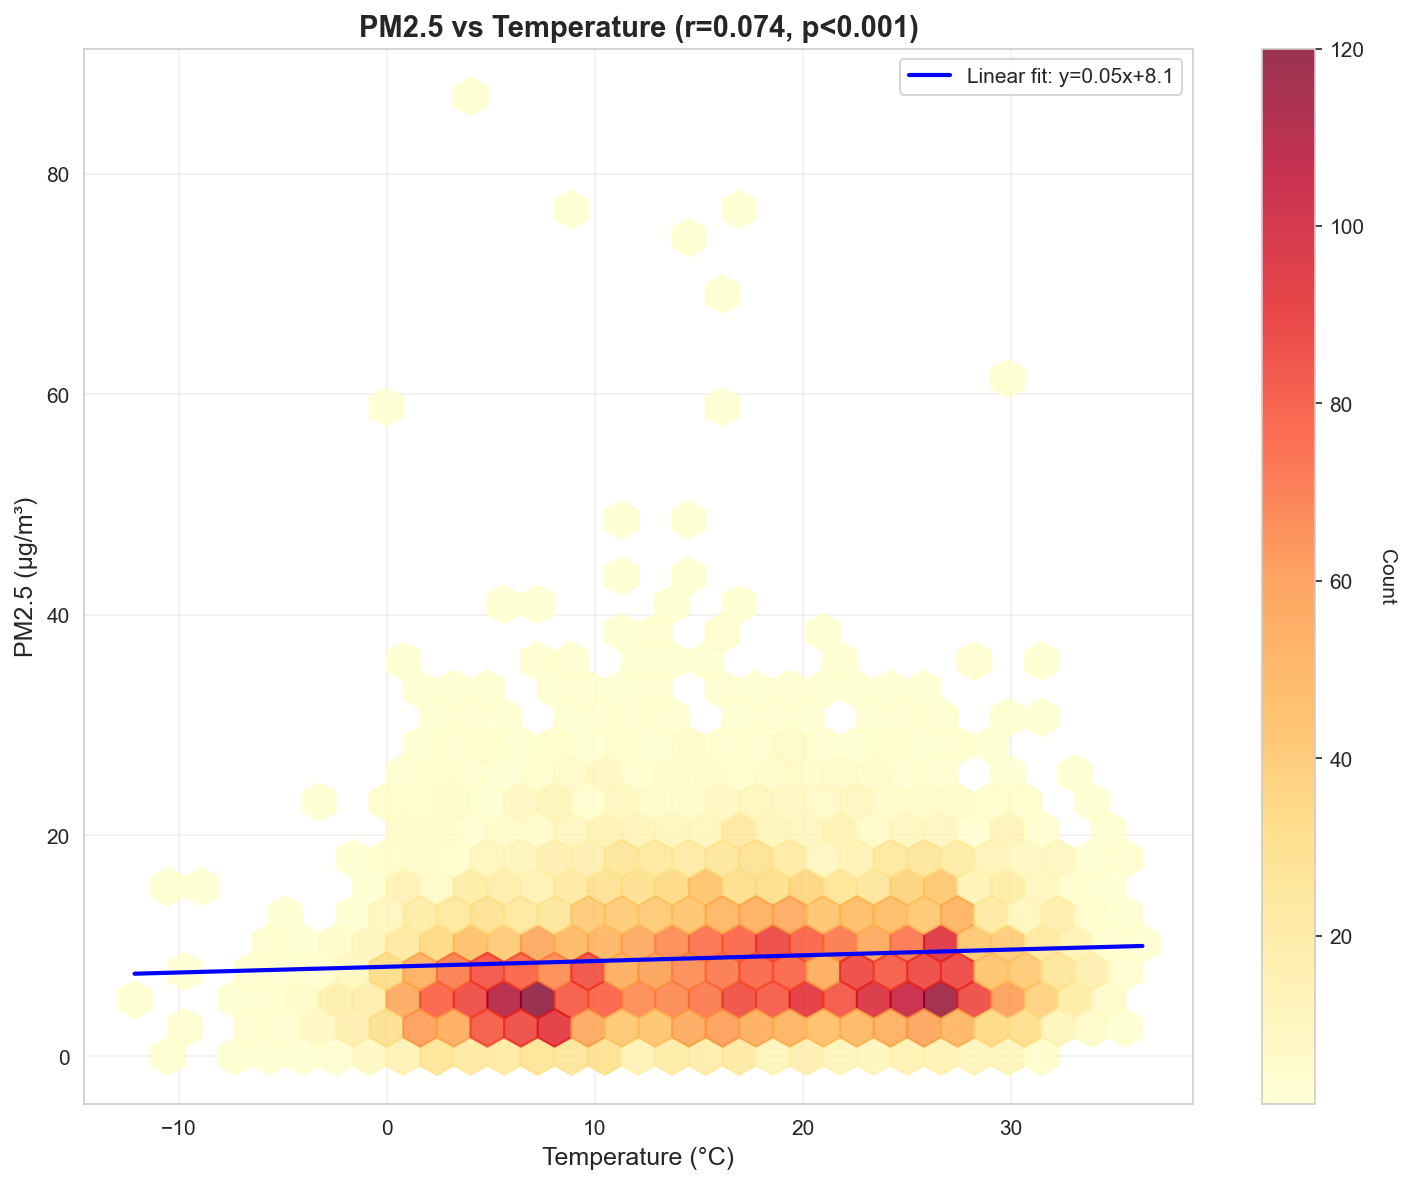

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sample = df.sample(n=min(10000, len(df)), random_state=42)
x = sample['temperature_c_mean']
y = sample['pm25_ugm3_mean']

valid_mask = x.notna() & y.notna()
x_valid = x[valid_mask]
y_valid = y[valid_mask]

hexbin = ax.hexbin(x_valid, y_valid, gridsize=30, cmap='YlOrRd', mincnt=1, alpha=0.8)
z = np.polyfit(x_valid, y_valid, 1)
p = np.poly1d(z)
ax.plot(x_valid.sort_values(), p(x_valid.sort_values()), "b-", linewidth=2, label=f'Linear fit: y={z[0]:.2f}x+{z[1]:.1f}')

corr, pval = pearsonr(x_valid, y_valid)
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title(f'PM2.5 vs Temperature (r={corr:.3f}, p<0.001)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Count', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('graphs/weather/01_pm25_vs_temperature_scatter.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/01_pm25_vs_temperature_scatter.png")
plt.show()

## 2. PM2.5 vs Temperature by Season

Saved: graphs/weather/02_pm25_vs_temp_seasonal.png


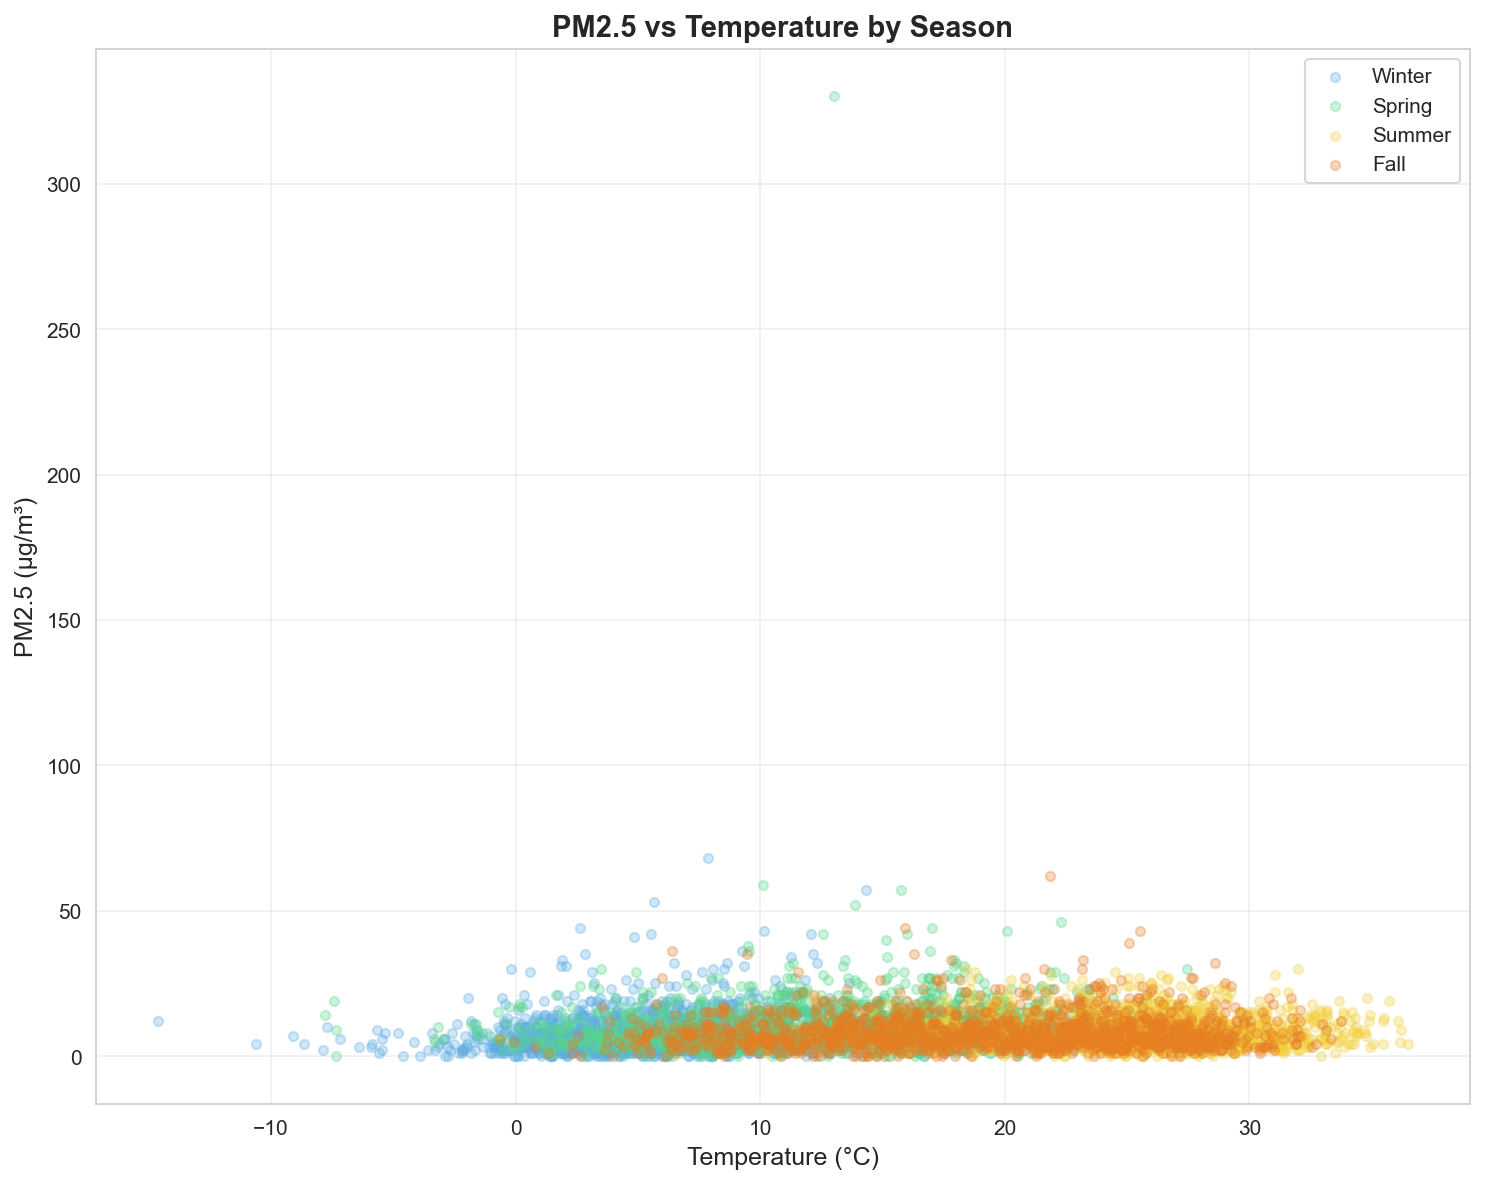

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = {'Winter': '#5DADE2', 'Spring': '#58D68D', 'Summer': '#F4D03F', 'Fall': '#E67E22'}
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

for season in season_order:
    season_data = df[df['season'] == season].sample(n=min(2000, len(df[df['season']==season])), random_state=42)
    x = season_data['temperature_c_mean']
    y = season_data['pm25_ugm3_mean']
    valid = x.notna() & y.notna()
    ax.scatter(x[valid], y[valid], alpha=0.3, s=20, color=colors[season], label=season)

ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('PM2.5 vs Temperature by Season', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('graphs/weather/02_pm25_vs_temp_seasonal.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/02_pm25_vs_temp_seasonal.png")
plt.show()

## 3. PM2.5 vs Humidity Scatter Plot

Saved: graphs/weather/03_pm25_vs_humidity_scatter.png


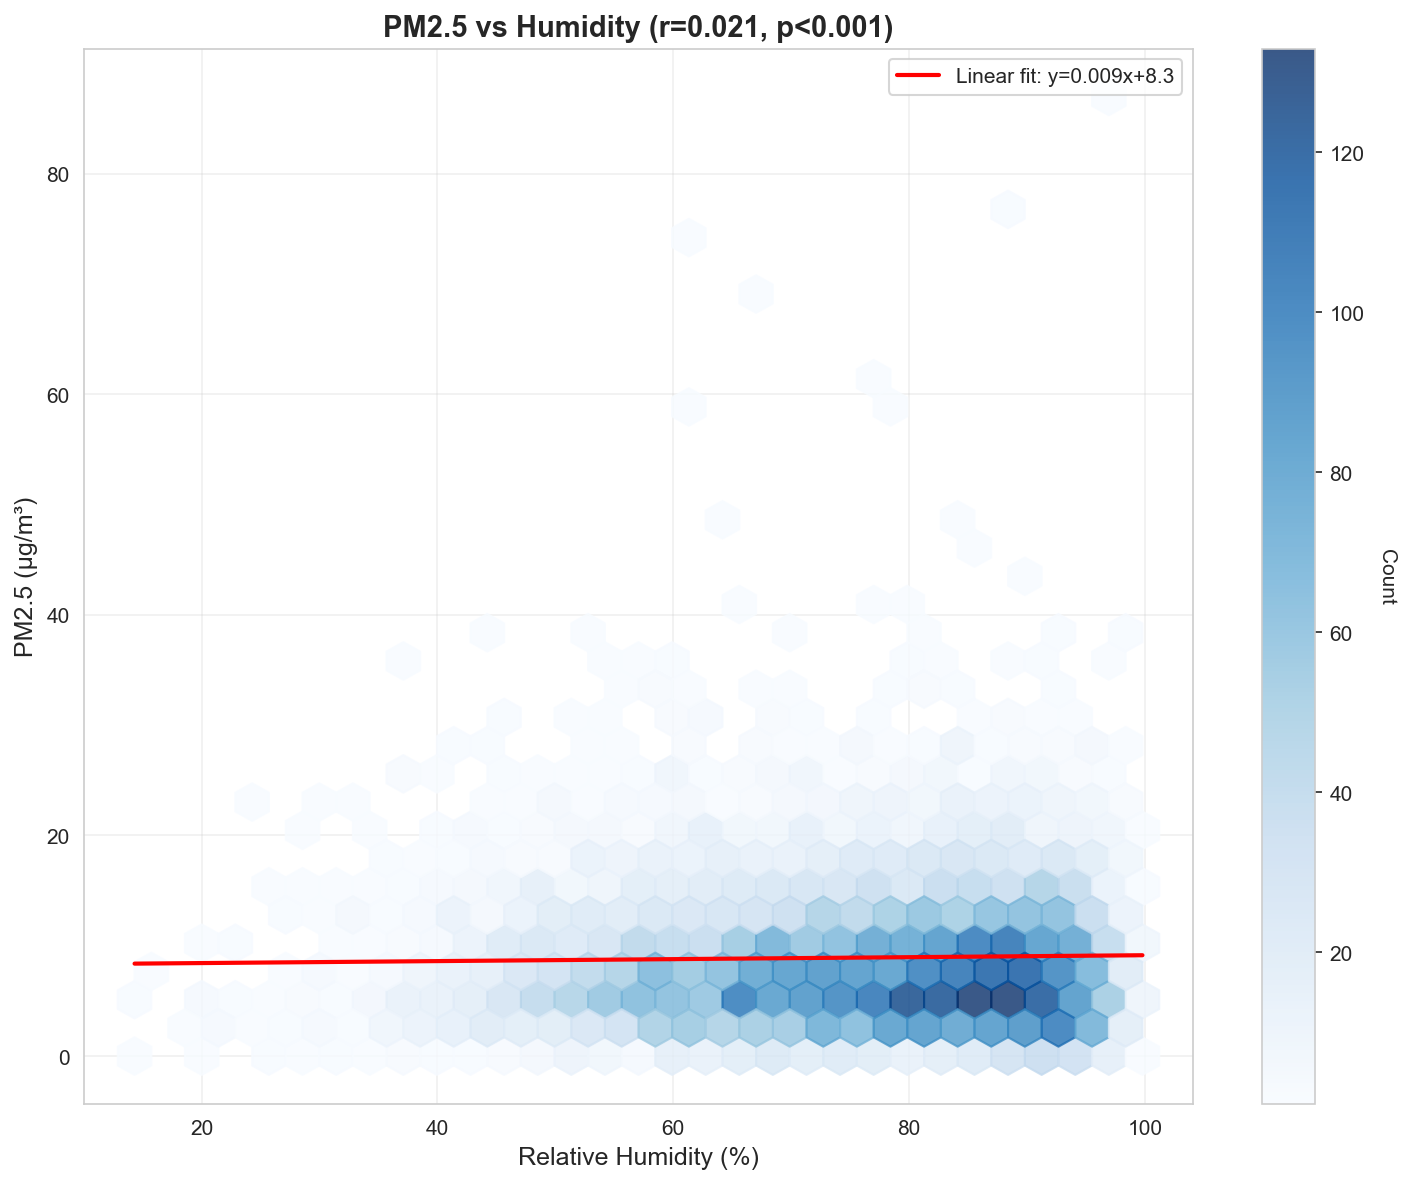

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sample = df.sample(n=min(10000, len(df)), random_state=42)
x = sample['humidity_pct_mean']
y = sample['pm25_ugm3_mean']

valid_mask = x.notna() & y.notna()
x_valid = x[valid_mask]
y_valid = y[valid_mask]

hexbin = ax.hexbin(x_valid, y_valid, gridsize=30, cmap='Blues', mincnt=1, alpha=0.8)
z = np.polyfit(x_valid, y_valid, 1)
p = np.poly1d(z)
ax.plot(x_valid.sort_values(), p(x_valid.sort_values()), "r-", linewidth=2, label=f'Linear fit: y={z[0]:.3f}x+{z[1]:.1f}')

corr, pval = pearsonr(x_valid, y_valid)
ax.set_xlabel('Relative Humidity (%)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title(f'PM2.5 vs Humidity (r={corr:.3f}, p<0.001)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Count', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('graphs/weather/03_pm25_vs_humidity_scatter.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/03_pm25_vs_humidity_scatter.png")
plt.show()

## 4. PM2.5 vs Cloud Cover

Saved: graphs/weather/04_pm25_vs_cloud_cover.png


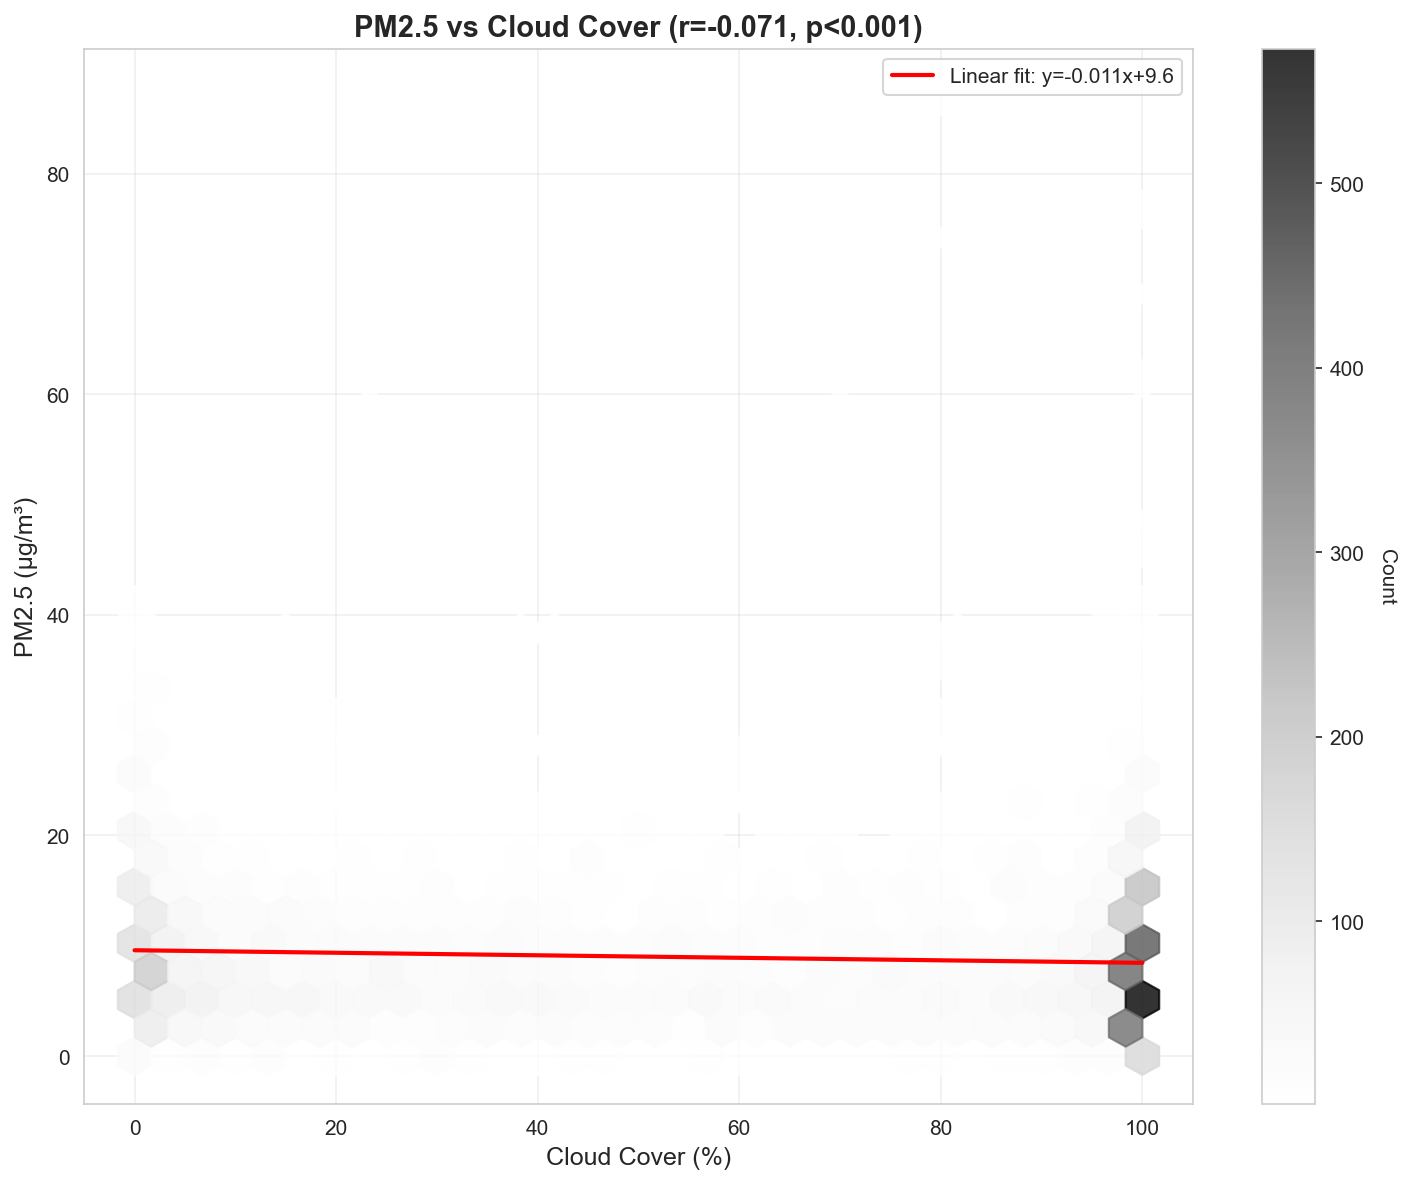

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sample = df.sample(n=min(10000, len(df)), random_state=42)
x = sample['cloud_cover_pct_mean']
y = sample['pm25_ugm3_mean']

valid_mask = x.notna() & y.notna()
x_valid = x[valid_mask]
y_valid = y[valid_mask]

hexbin = ax.hexbin(x_valid, y_valid, gridsize=30, cmap='Greys', mincnt=1, alpha=0.8)
z = np.polyfit(x_valid, y_valid, 1)
p = np.poly1d(z)
ax.plot(x_valid.sort_values(), p(x_valid.sort_values()), "r-", linewidth=2, label=f'Linear fit: y={z[0]:.3f}x+{z[1]:.1f}')

corr, pval = pearsonr(x_valid, y_valid)
ax.set_xlabel('Cloud Cover (%)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title(f'PM2.5 vs Cloud Cover (r={corr:.3f}, p<0.001)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Count', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig('graphs/weather/04_pm25_vs_cloud_cover.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/04_pm25_vs_cloud_cover.png")
plt.show()

## 5. PM2.5 vs Precipitation

Saved: graphs/weather/05_pm25_vs_precipitation.png


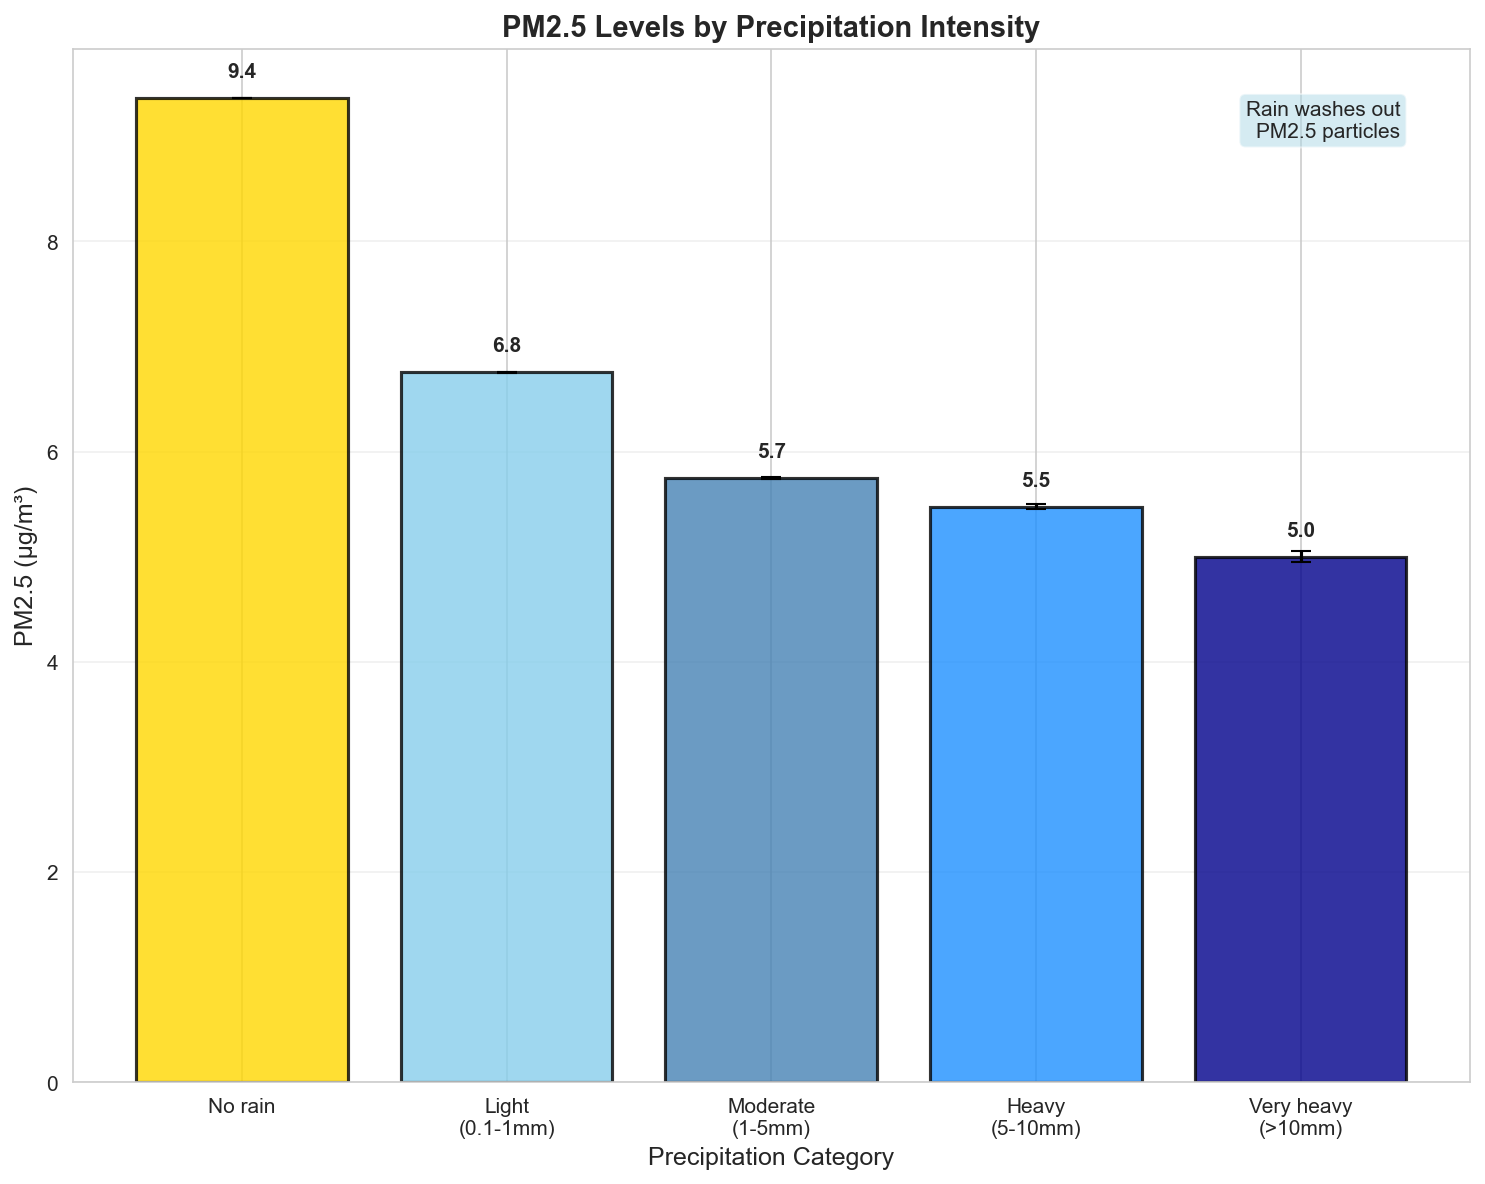

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

df['precip_category'] = pd.cut(df['precipitation_mm_mean'], 
                               bins=[-np.inf, 0.1, 1, 5, 10, np.inf],
                               labels=['No rain', 'Light\n(0.1-1mm)', 'Moderate\n(1-5mm)', 
                                      'Heavy\n(5-10mm)', 'Very heavy\n(>10mm)'])

precip_pm25 = df.groupby('precip_category')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
precip_pm25['sem'] = precip_pm25['std'] / np.sqrt(precip_pm25['count'])

bars = ax.bar(range(len(precip_pm25)), precip_pm25['mean'], 
              yerr=precip_pm25['sem'], capsize=5,
              color=['#FFD700', '#87CEEB', '#4682B4', '#1E90FF', '#00008B'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Precipitation Category', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title('PM2.5 Levels by Precipitation Intensity', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(precip_pm25)))
ax.set_xticklabels(precip_pm25.index)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, precip_pm25['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
           f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.text(0.95, 0.95, 'Rain washes out\nPM2.5 particles', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('graphs/weather/05_pm25_vs_precipitation.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/05_pm25_vs_precipitation.png")
plt.show()

## 6. Weather Variables Correlation Matrix

Saved: graphs/weather/06_weather_correlation_matrix.png


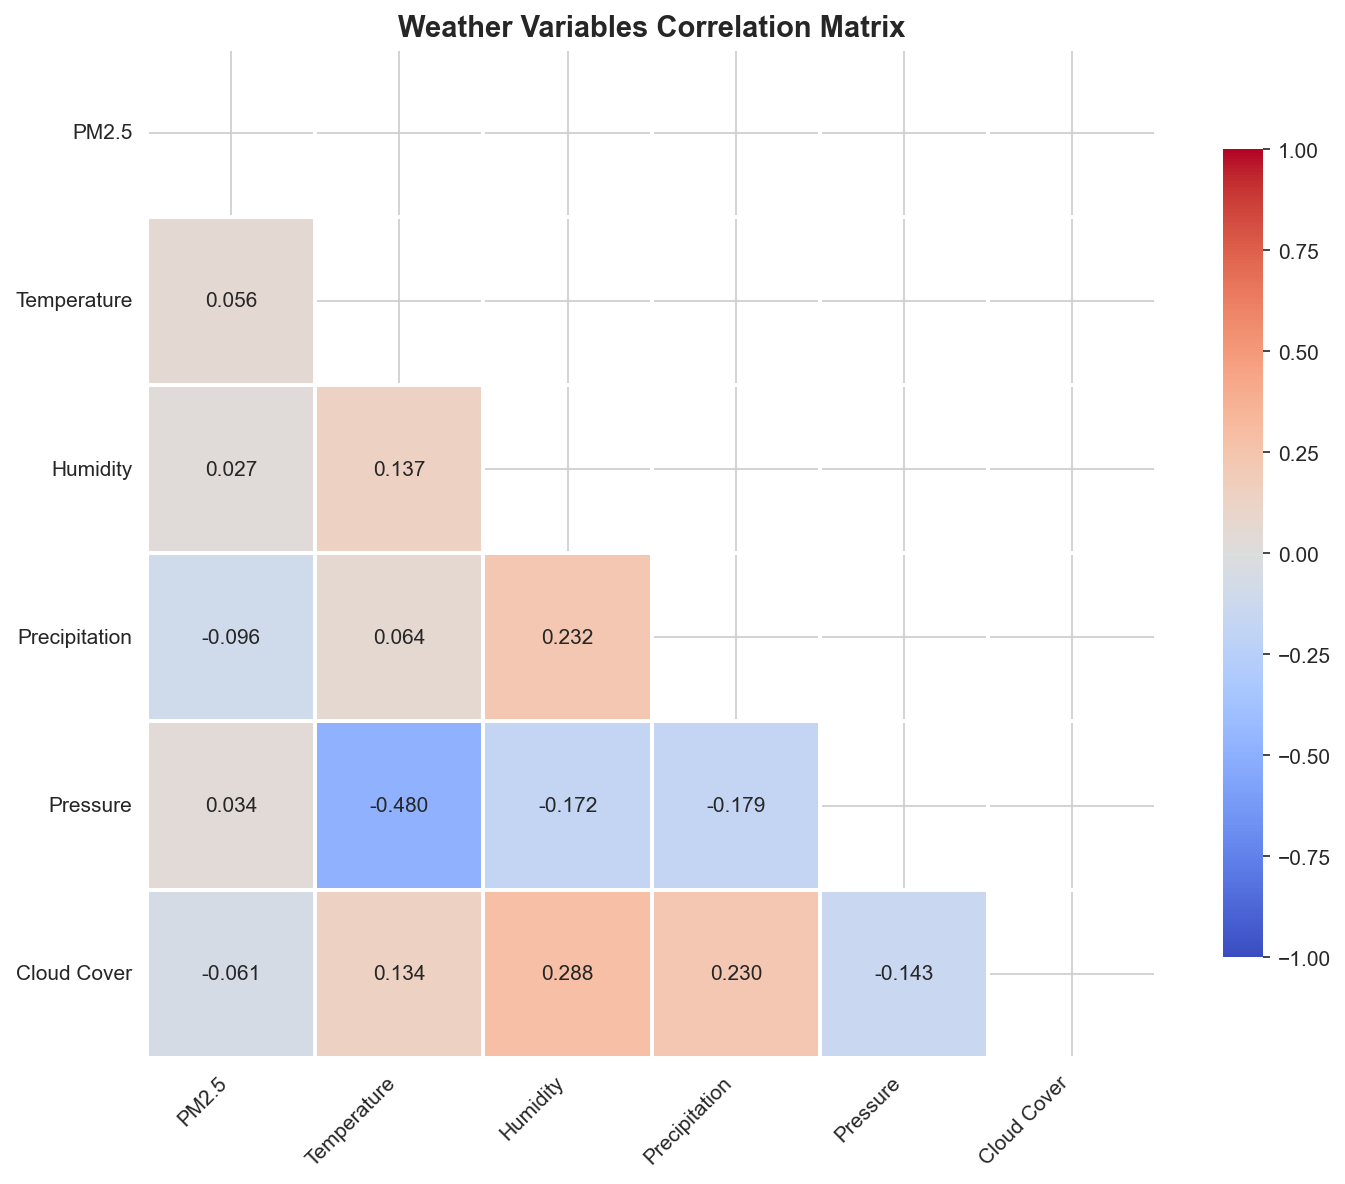

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

weather_vars = ['pm25_ugm3_mean', 'temperature_c_mean', 'humidity_pct_mean', 
               'precipitation_mm_mean', 'pressure_hpa_mean', 'cloud_cover_pct_mean']
weather_df = df[weather_vars].dropna()

corr_matrix = weather_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax, vmin=-1, vmax=1)

labels = ['PM2.5', 'Temperature', 'Humidity', 'Precipitation', 'Pressure', 'Cloud Cover']
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels, rotation=0)
ax.set_title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('graphs/weather/06_weather_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/06_weather_correlation_matrix.png")
plt.show()

## 7. PM2.5 and Temperature Monthly Trends

Saved: graphs/weather/07_pm25_temp_monthly_trends.png


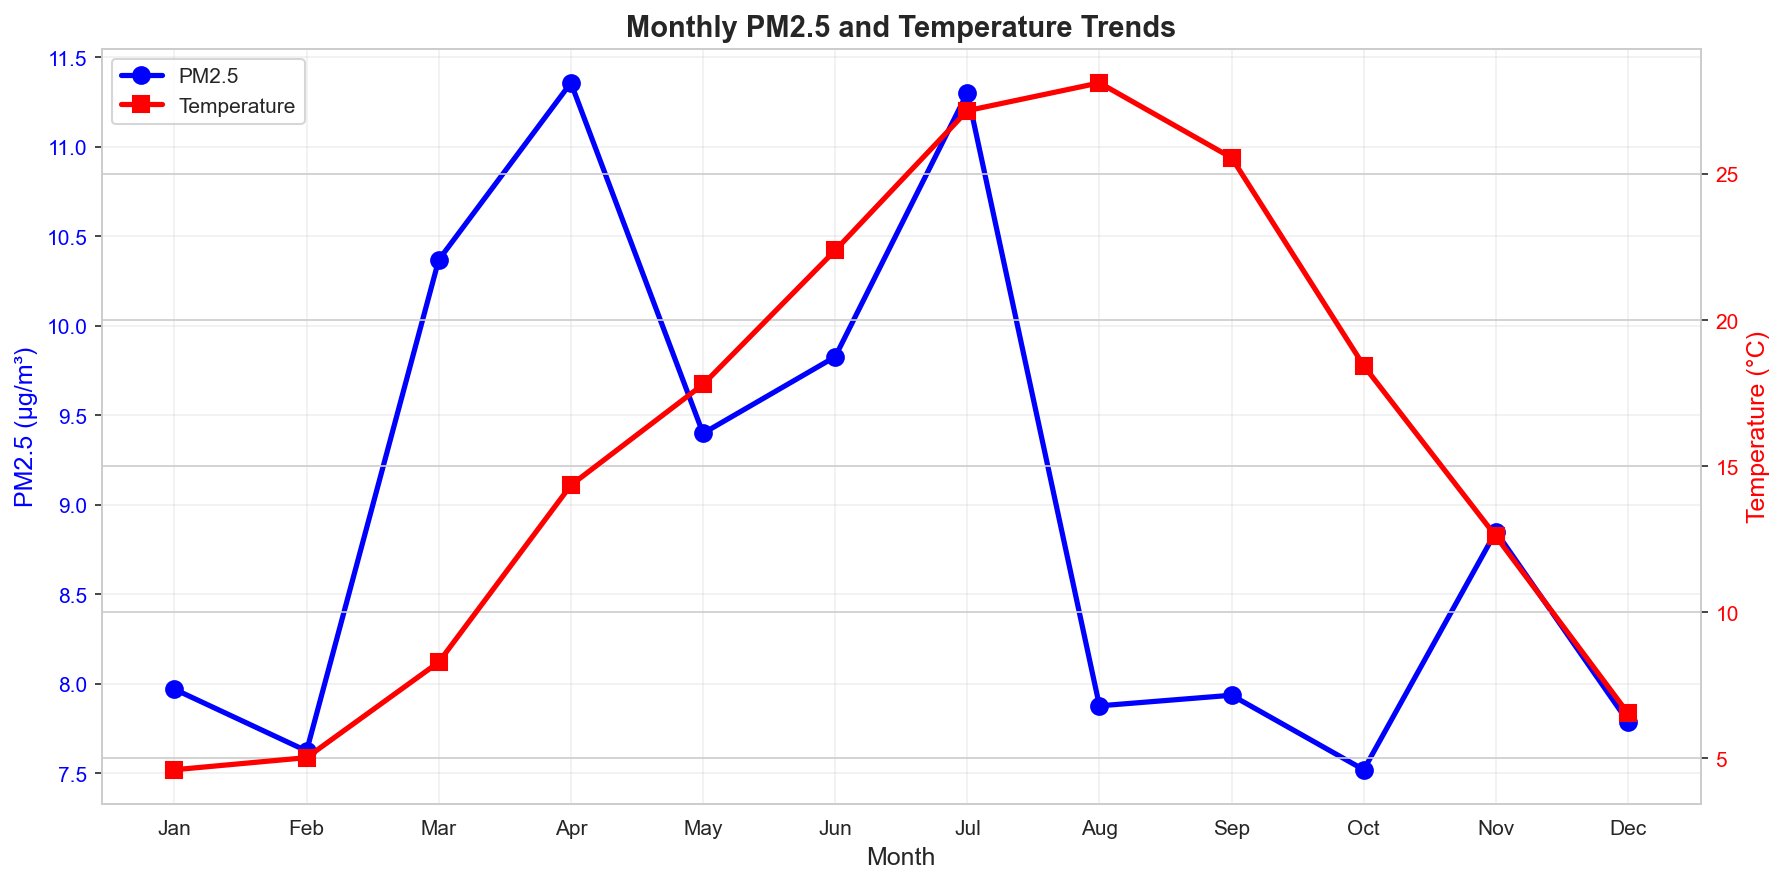

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats = df.groupby('month')[['pm25_ugm3_mean', 'temperature_c_mean']].mean()

ax2 = ax.twinx()
l1 = ax.plot(monthly_stats.index, monthly_stats['pm25_ugm3_mean'], 'b-o', 
            linewidth=2.5, markersize=8, label='PM2.5')
l2 = ax2.plot(monthly_stats.index, monthly_stats['temperature_c_mean'], 'r-s', 
             linewidth=2.5, markersize=8, label='Temperature')

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', color='b', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='r', fontsize=12)
ax.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='r')
ax.set_title('Monthly PM2.5 and Temperature Trends', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.grid(True, alpha=0.3)

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('graphs/weather/07_pm25_temp_monthly_trends.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/07_pm25_temp_monthly_trends.png")
plt.show()

## 8. PM2.5 and Humidity Hourly Patterns

Saved: graphs/weather/08_pm25_humidity_hourly.png


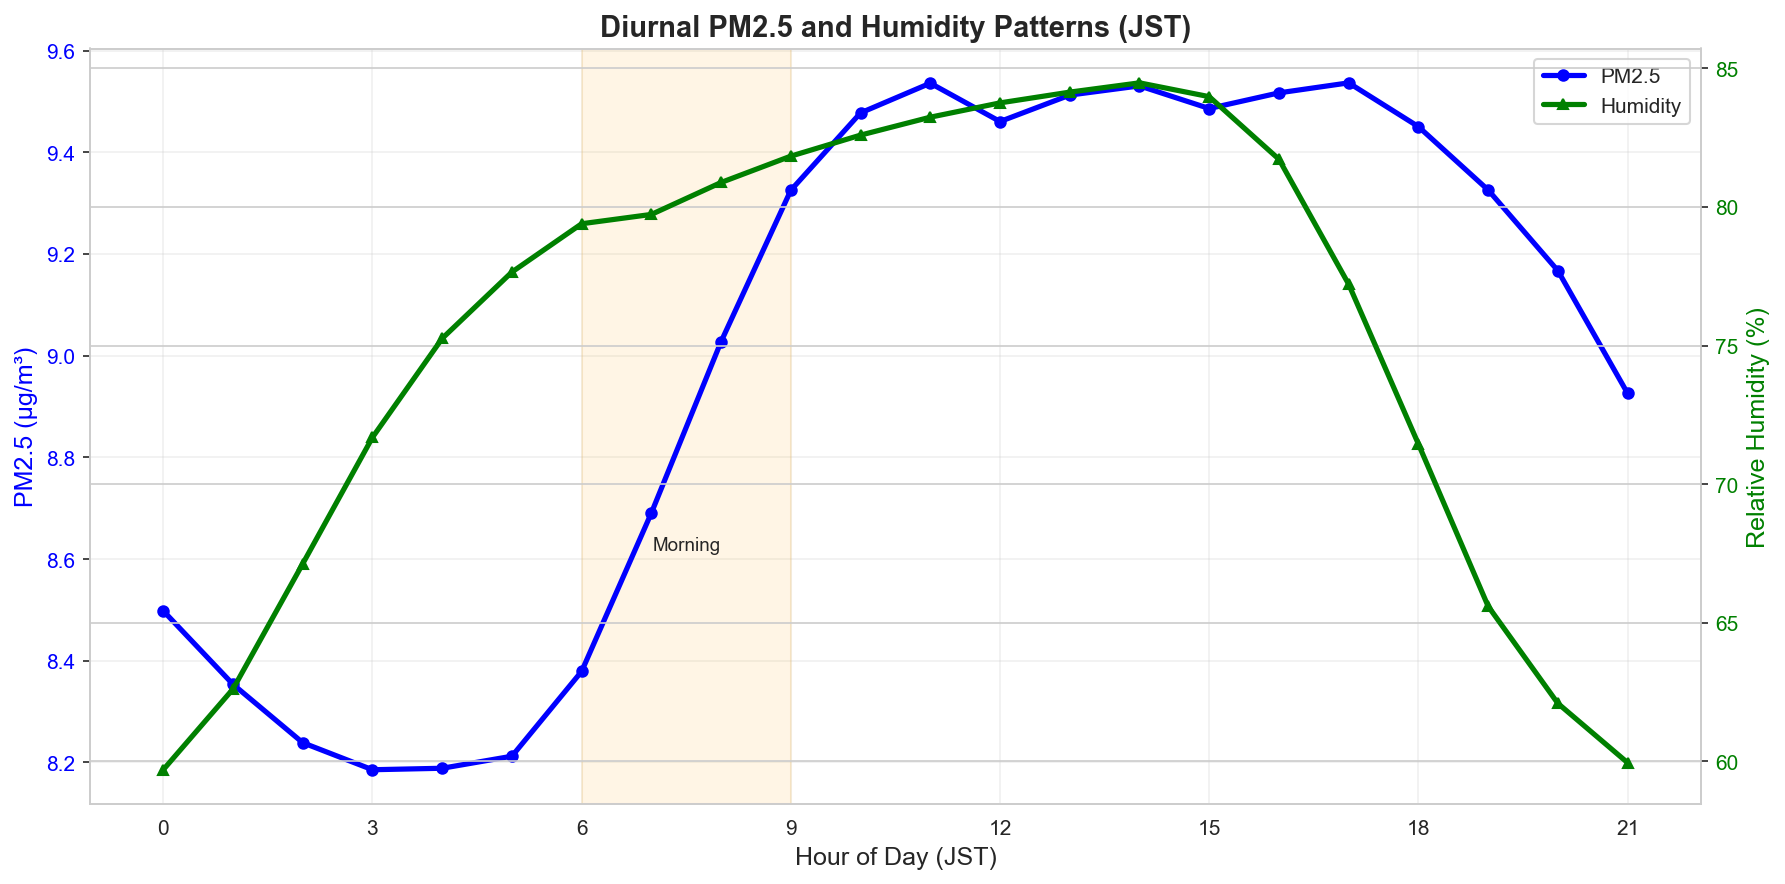

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

hourly_stats = df.groupby('hour')[['pm25_ugm3_mean', 'humidity_pct_mean']].mean()

ax2 = ax.twinx()
l1 = ax.plot(hourly_stats.index, hourly_stats['pm25_ugm3_mean'], 'b-', 
            linewidth=2.5, label='PM2.5', marker='o', markersize=5)
l2 = ax2.plot(hourly_stats.index, hourly_stats['humidity_pct_mean'], 'g-', 
             linewidth=2.5, label='Humidity', marker='^', markersize=5)

ax.set_xlabel('Hour of Day (JST)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', color='b', fontsize=12)
ax2.set_ylabel('Relative Humidity (%)', color='g', fontsize=12)
ax.tick_params(axis='y', labelcolor='b')
ax2.tick_params(axis='y', labelcolor='g')
ax.set_title('Diurnal PM2.5 and Humidity Patterns (JST)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24, 3))
ax.grid(True, alpha=0.3)

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc='upper right')

ax.axvspan(6, 9, alpha=0.1, color='orange')
ax.text(7.5, ax.get_ylim()[0] + 0.5, 'Morning', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graphs/weather/08_pm25_humidity_hourly.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/08_pm25_humidity_hourly.png")
plt.show()

## 9. PM2.5 vs Solar Radiation

Saved: graphs/weather/09_pm25_vs_solar_radiation.png


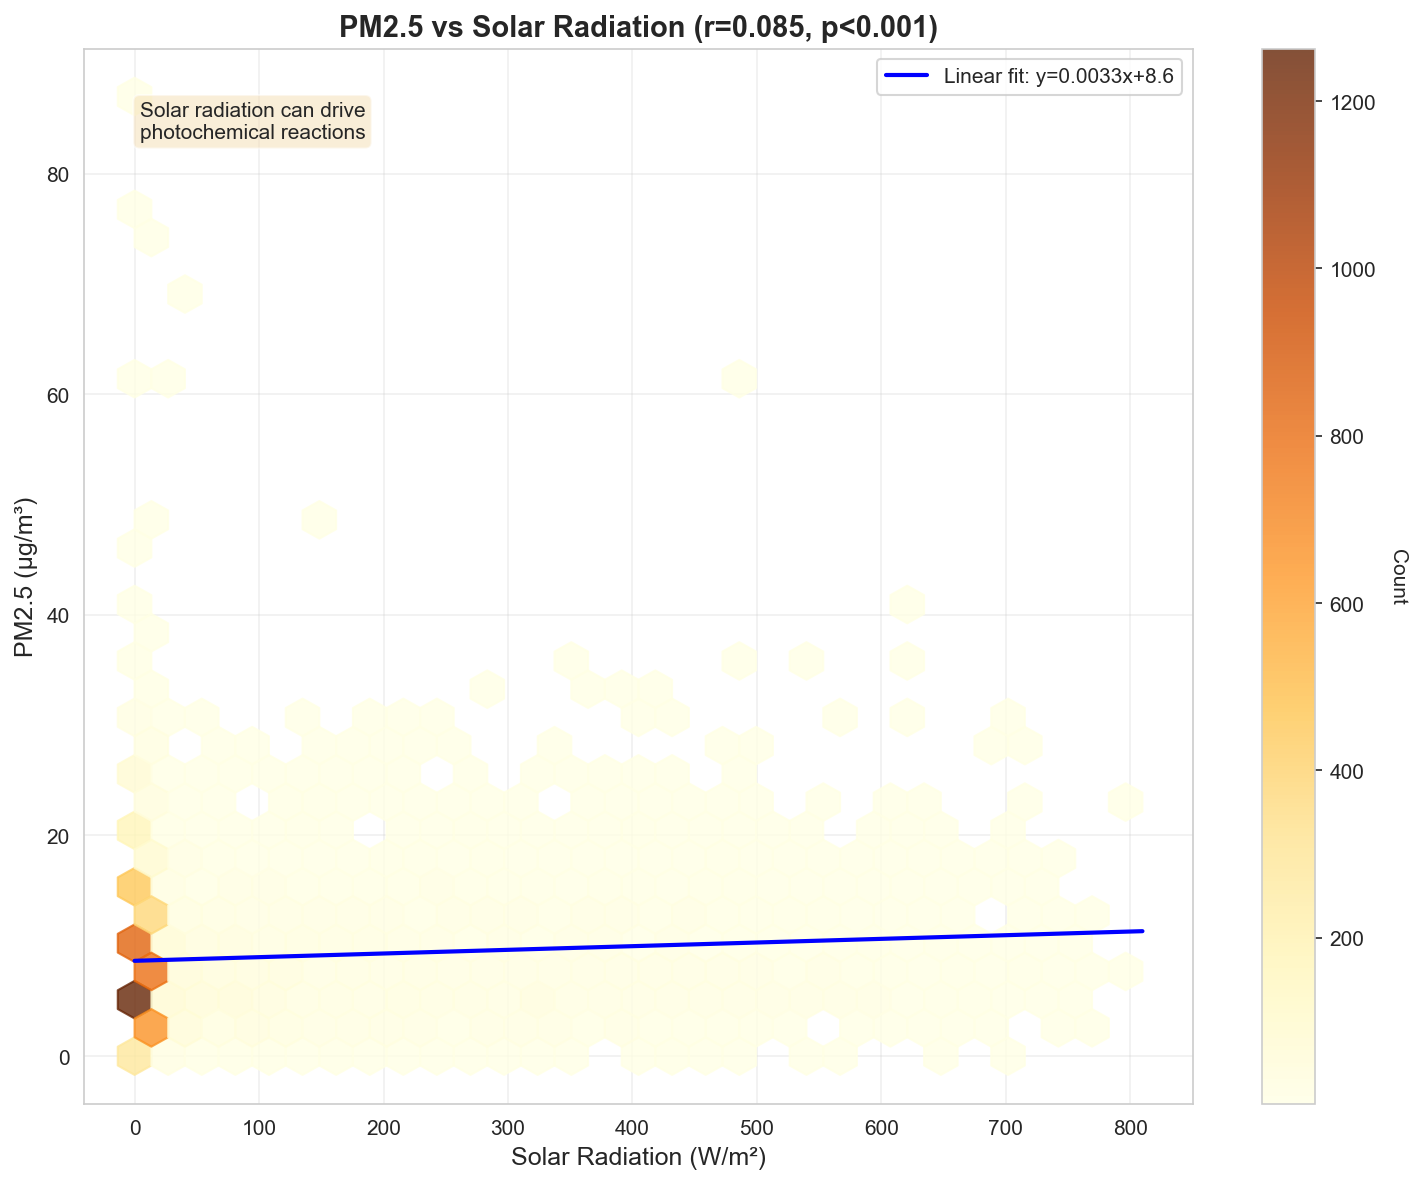

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sample = df.sample(n=min(10000, len(df)), random_state=42)
x = sample['solar_radiation_wm2_mean']
y = sample['pm25_ugm3_mean']

valid_mask = x.notna() & y.notna()
x_valid = x[valid_mask]
y_valid = y[valid_mask]

hexbin = ax.hexbin(x_valid, y_valid, gridsize=30, cmap='YlOrBr', mincnt=1, alpha=0.8)
z = np.polyfit(x_valid, y_valid, 1)
p = np.poly1d(z)
ax.plot(x_valid.sort_values(), p(x_valid.sort_values()), "b-", linewidth=2, 
       label=f'Linear fit: y={z[0]:.4f}x+{z[1]:.1f}')

corr, pval = pearsonr(x_valid, y_valid)
ax.set_xlabel('Solar Radiation (W/m²)', fontsize=12)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
ax.set_title(f'PM2.5 vs Solar Radiation (r={corr:.3f}, p<0.001)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Count', rotation=270, labelpad=15)

ax.text(0.05, 0.95, 'Solar radiation can drive\nphotochemical reactions', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('graphs/weather/09_pm25_vs_solar_radiation.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/09_pm25_vs_solar_radiation.png")
plt.show()

## 10. PM2.5 by Weather Conditions

Saved: graphs/weather/10_pm25_by_weather_conditions.png


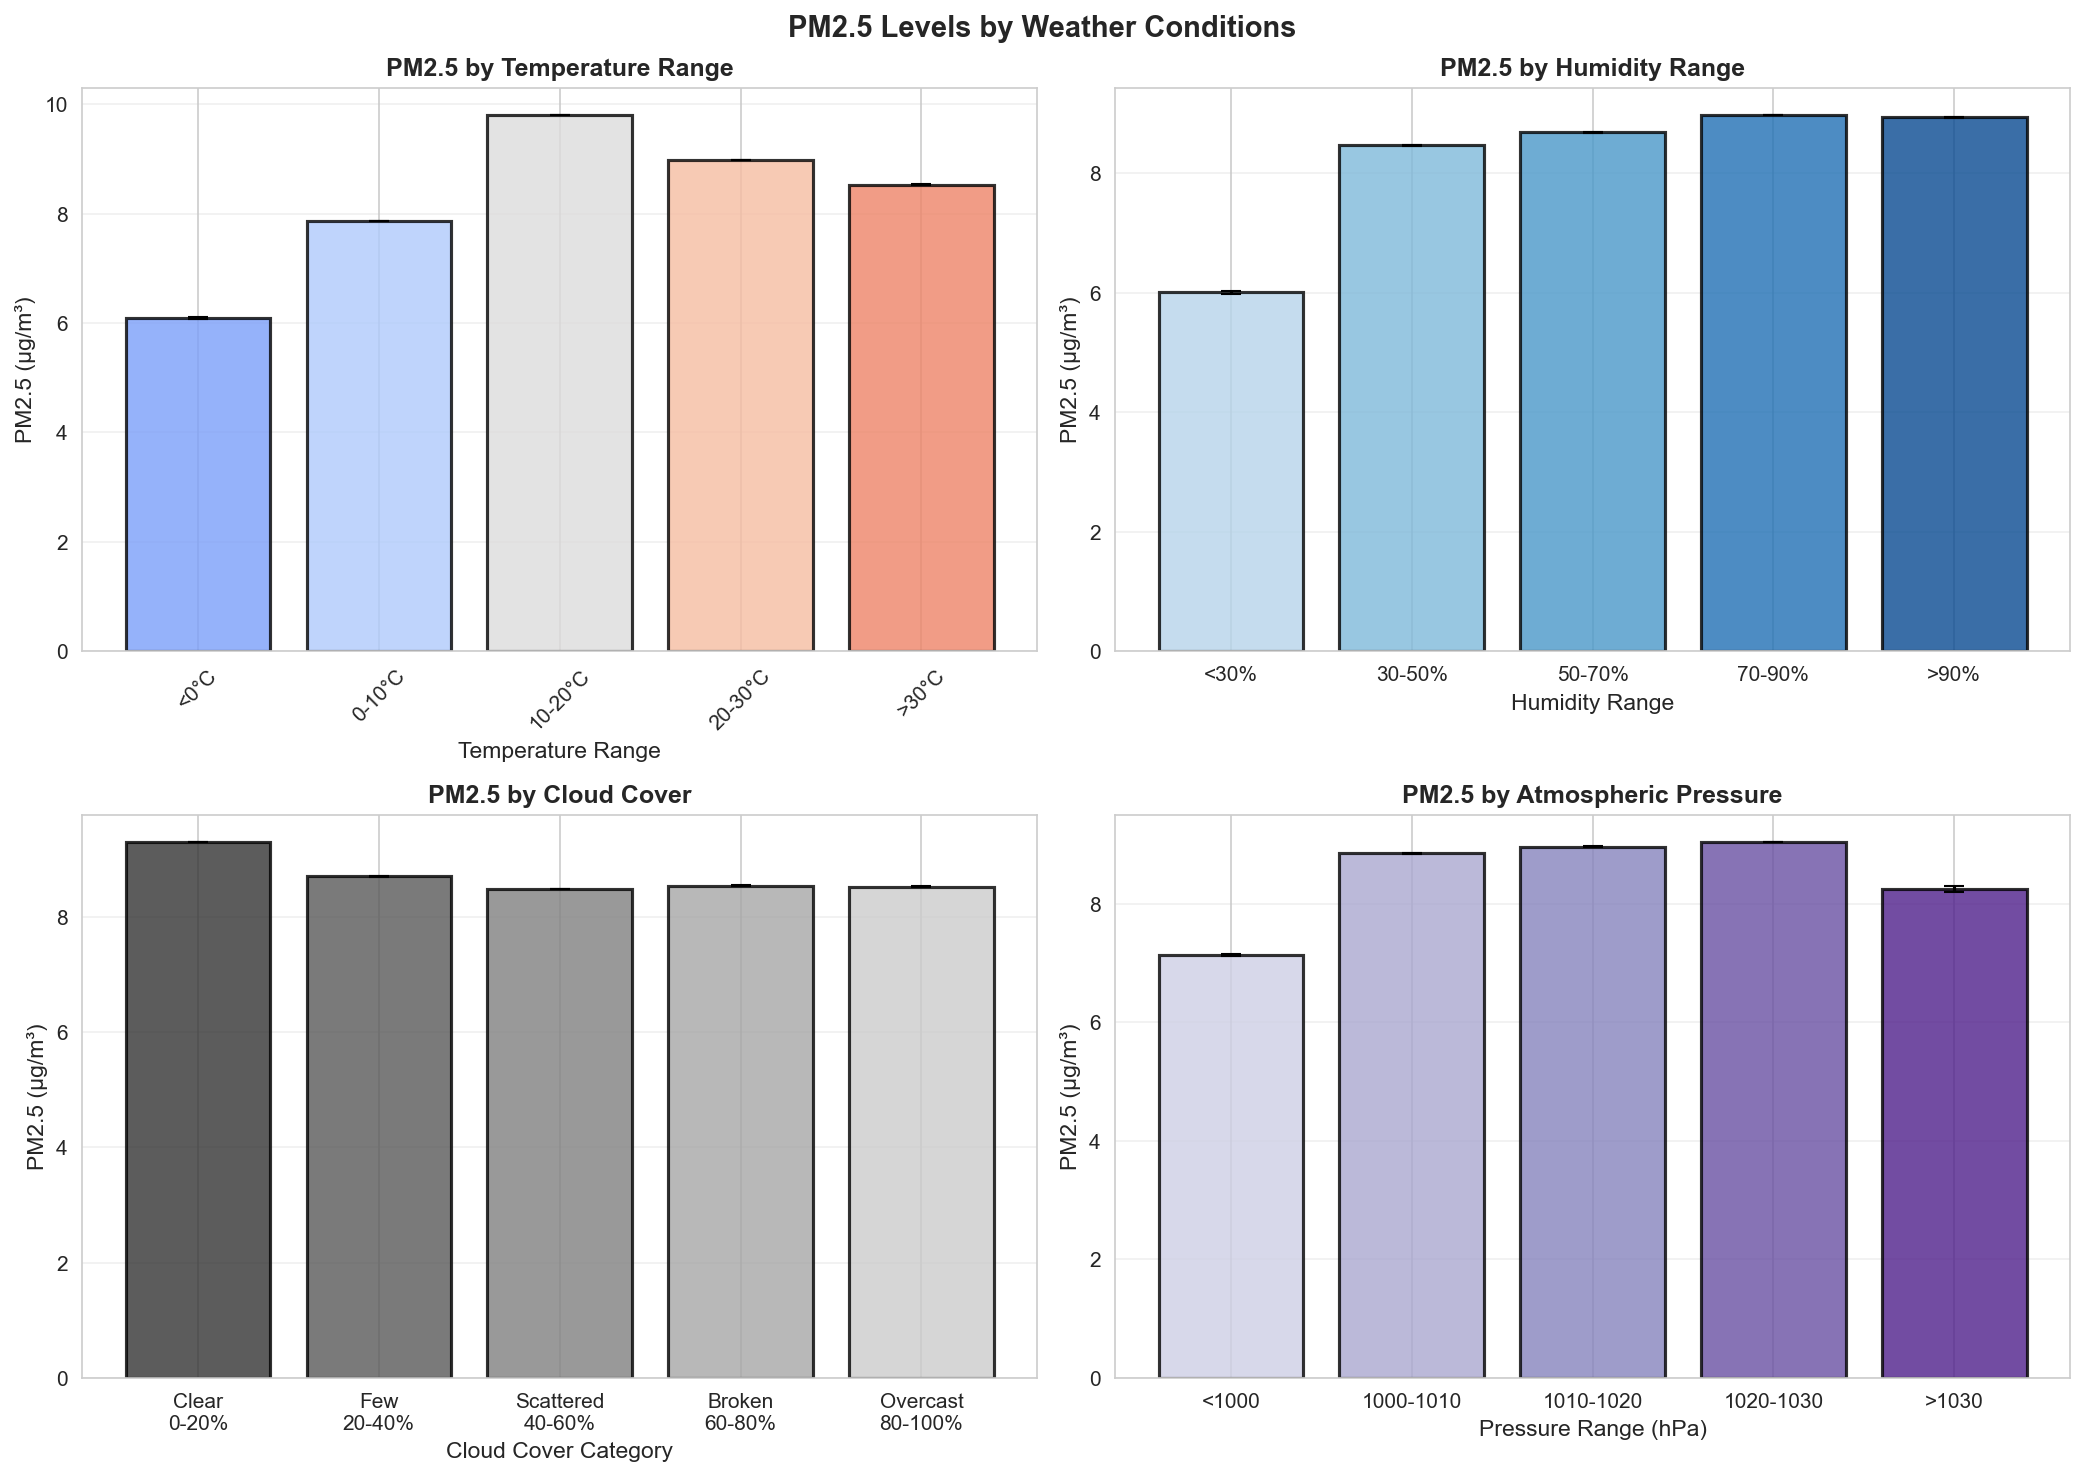

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature bins
ax = axes[0, 0]
df['temp_bin'] = pd.cut(df['temperature_c_mean'], 
                        bins=[-20, 0, 10, 20, 30, 40],
                        labels=['<0°C', '0-10°C', '10-20°C', '20-30°C', '>30°C'])
temp_pm25 = df.groupby('temp_bin')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
temp_pm25['sem'] = temp_pm25['std'] / np.sqrt(temp_pm25['count'])

bars = ax.bar(range(len(temp_pm25)), temp_pm25['mean'], 
              yerr=temp_pm25['sem'], capsize=5,
              color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(temp_pm25))),
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Temperature Range', fontsize=11)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax.set_title('PM2.5 by Temperature Range', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(temp_pm25)))
ax.set_xticklabels(temp_pm25.index, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Humidity bins
ax = axes[0, 1]
df['humid_bin'] = pd.cut(df['humidity_pct_mean'], 
                         bins=[0, 30, 50, 70, 90, 100],
                         labels=['<30%', '30-50%', '50-70%', '70-90%', '>90%'])
humid_pm25 = df.groupby('humid_bin')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
humid_pm25['sem'] = humid_pm25['std'] / np.sqrt(humid_pm25['count'])

bars = ax.bar(range(len(humid_pm25)), humid_pm25['mean'], 
              yerr=humid_pm25['sem'], capsize=5,
              color=plt.cm.Blues(np.linspace(0.3, 0.9, len(humid_pm25))),
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Humidity Range', fontsize=11)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax.set_title('PM2.5 by Humidity Range', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(humid_pm25)))
ax.set_xticklabels(humid_pm25.index)
ax.grid(True, alpha=0.3, axis='y')

# Cloud cover bins
ax = axes[1, 0]
df['cloud_bin'] = pd.cut(df['cloud_cover_pct_mean'], 
                        bins=[0, 20, 40, 60, 80, 100],
                        labels=['Clear\n0-20%', 'Few\n20-40%', 'Scattered\n40-60%', 
                               'Broken\n60-80%', 'Overcast\n80-100%'])
cloud_pm25 = df.groupby('cloud_bin')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
cloud_pm25['sem'] = cloud_pm25['std'] / np.sqrt(cloud_pm25['count'])

bars = ax.bar(range(len(cloud_pm25)), cloud_pm25['mean'], 
              yerr=cloud_pm25['sem'], capsize=5,
              color=plt.cm.gray(np.linspace(0.2, 0.8, len(cloud_pm25))),
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Cloud Cover Category', fontsize=11)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax.set_title('PM2.5 by Cloud Cover', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(cloud_pm25)))
ax.set_xticklabels(cloud_pm25.index)
ax.grid(True, alpha=0.3, axis='y')

# Pressure bins
ax = axes[1, 1]
df['pressure_bin'] = pd.cut(df['pressure_hpa_mean'], 
                           bins=[980, 1000, 1010, 1020, 1030, 1050],
                           labels=['<1000', '1000-1010', '1010-1020', '1020-1030', '>1030'])
pressure_pm25 = df.groupby('pressure_bin')['pm25_ugm3_mean'].agg(['mean', 'std', 'count'])
pressure_pm25['sem'] = pressure_pm25['std'] / np.sqrt(pressure_pm25['count'])

bars = ax.bar(range(len(pressure_pm25)), pressure_pm25['mean'], 
              yerr=pressure_pm25['sem'], capsize=5,
              color=plt.cm.Purples(np.linspace(0.3, 0.9, len(pressure_pm25))),
              edgecolor='black', linewidth=1.5, alpha=0.8)
ax.set_xlabel('Pressure Range (hPa)', fontsize=11)
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax.set_title('PM2.5 by Atmospheric Pressure', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(pressure_pm25)))
ax.set_xticklabels(pressure_pm25.index)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('PM2.5 Levels by Weather Conditions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/weather/10_pm25_by_weather_conditions.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/10_pm25_by_weather_conditions.png")
plt.show()

## 11. Time Series: PM2.5, Temperature, and Humidity

Saved: graphs/weather/11_timeseries_pm25_temp_humid.png


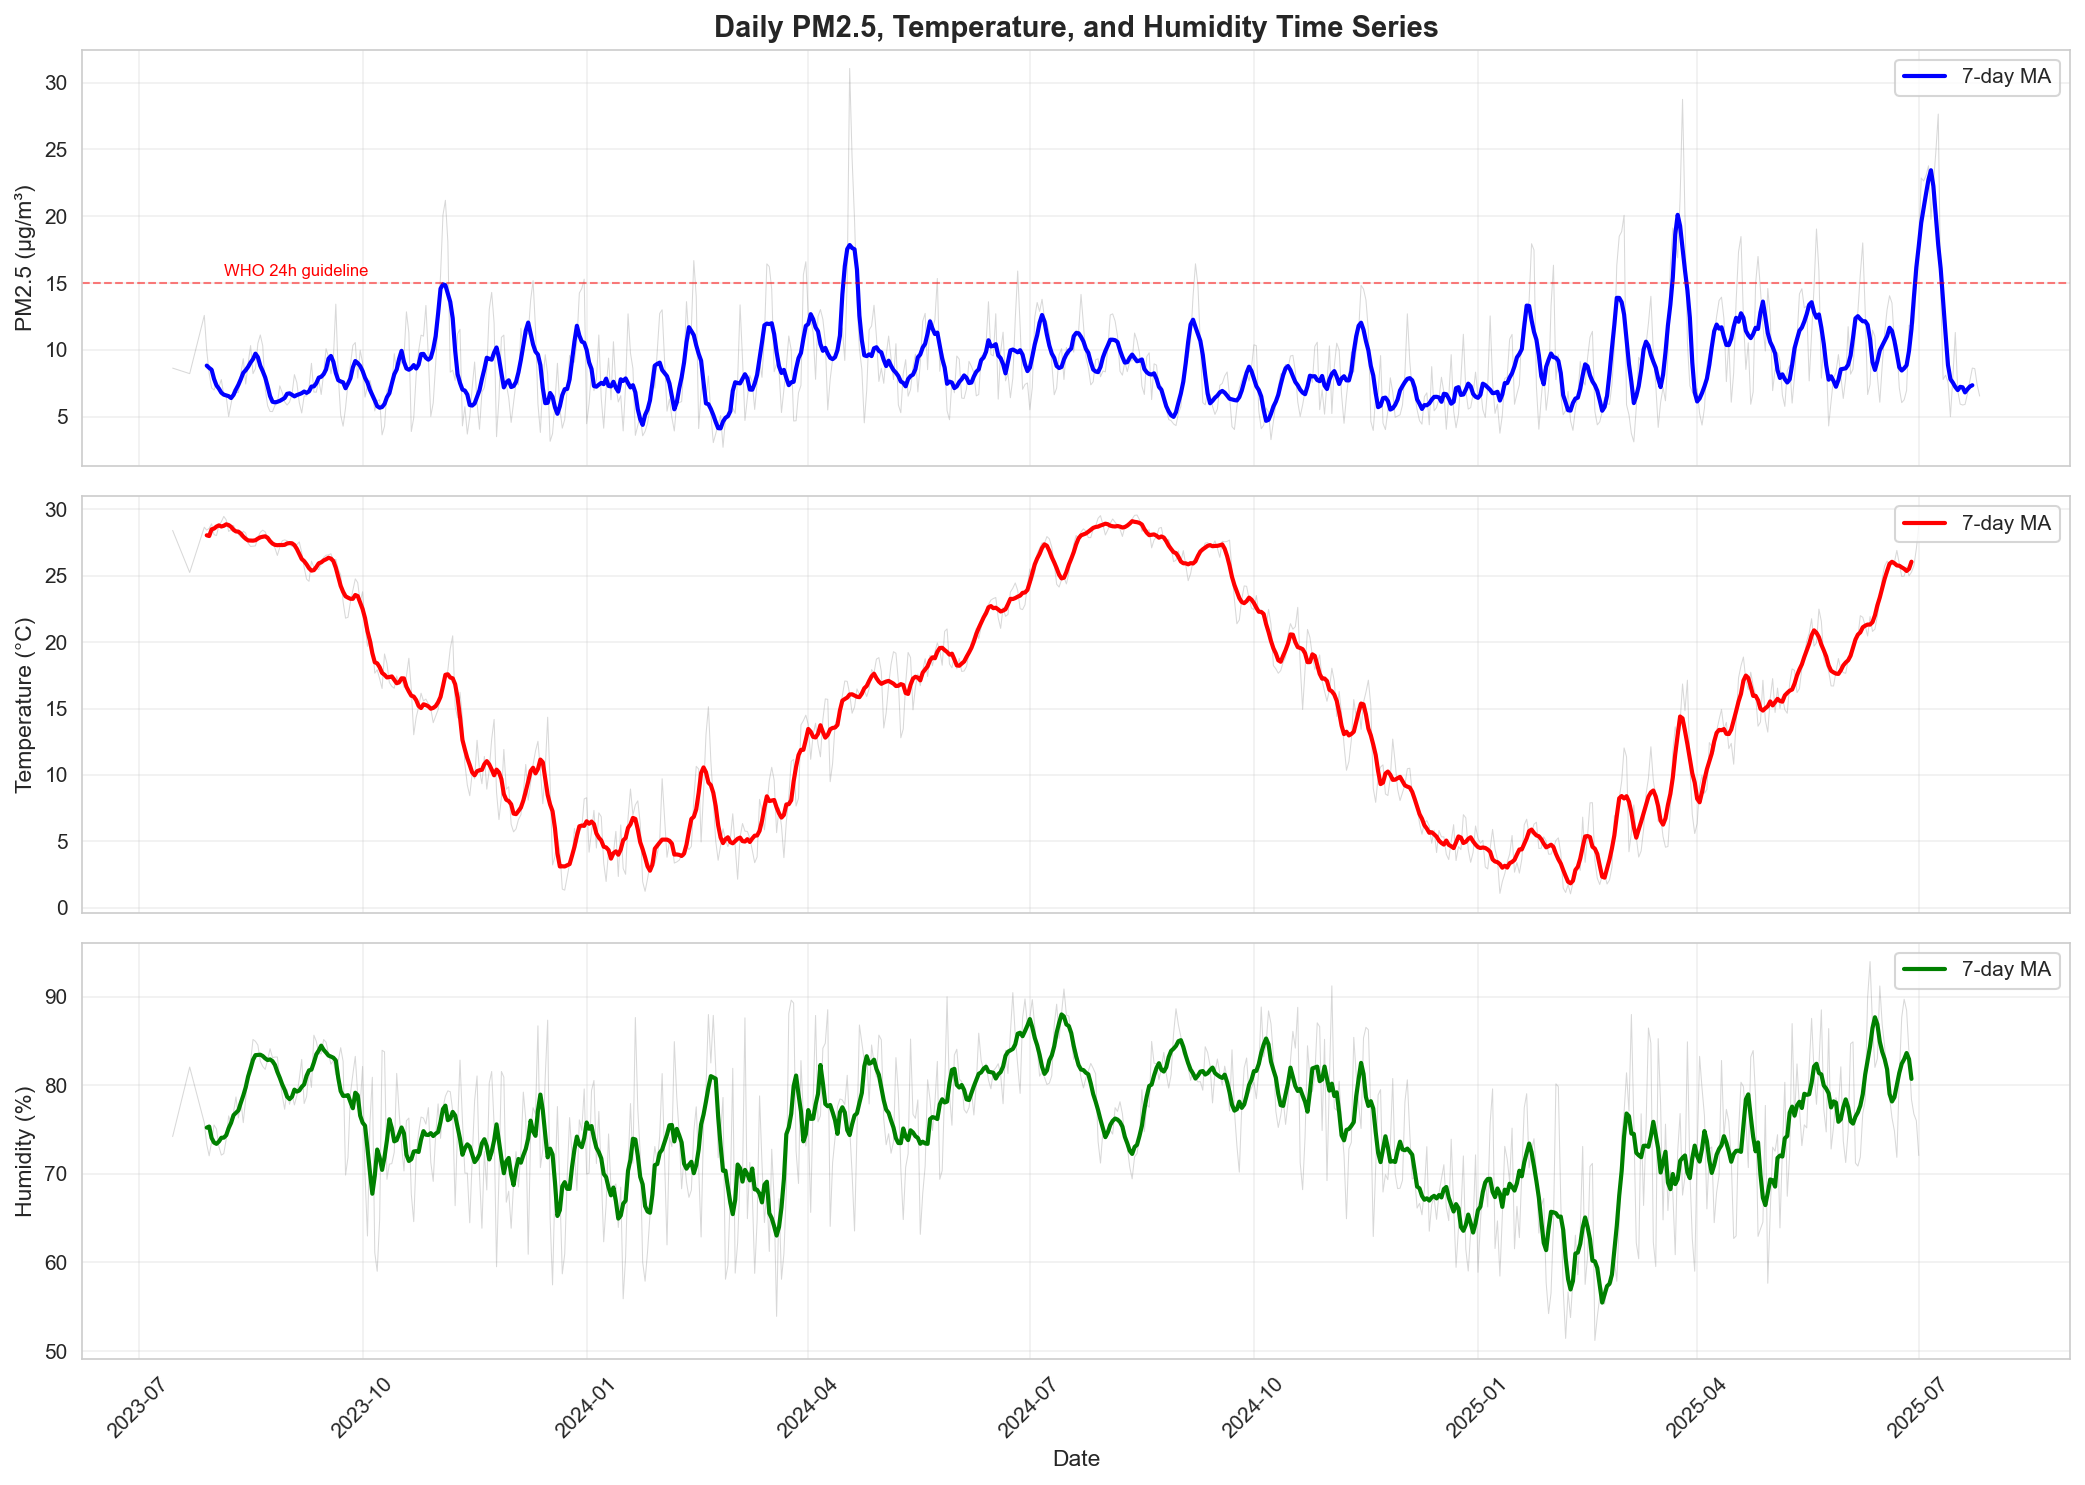

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

daily_stats = df.groupby('date')[['pm25_ugm3_mean', 'temperature_c_mean', 'humidity_pct_mean']].mean()
rolling = daily_stats.rolling(window=7, center=True).mean()

# PM2.5
ax = axes[0]
ax.plot(daily_stats.index, daily_stats['pm25_ugm3_mean'], alpha=0.3, linewidth=0.5, color='gray')
ax.plot(rolling.index, rolling['pm25_ugm3_mean'], linewidth=2, color='blue', label='7-day MA')
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax.set_title('Daily PM2.5, Temperature, and Humidity Time Series', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.axhline(y=15, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(daily_stats.index[10], 15.5, 'WHO 24h guideline', fontsize=8, color='red')

# Temperature
ax = axes[1]
ax.plot(daily_stats.index, daily_stats['temperature_c_mean'], alpha=0.3, linewidth=0.5, color='gray')
ax.plot(rolling.index, rolling['temperature_c_mean'], linewidth=2, color='red', label='7-day MA')
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

# Humidity
ax = axes[2]
ax.plot(daily_stats.index, daily_stats['humidity_pct_mean'], alpha=0.3, linewidth=0.5, color='gray')
ax.plot(rolling.index, rolling['humidity_pct_mean'], linewidth=2, color='green', label='7-day MA')
ax.set_ylabel('Humidity (%)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('graphs/weather/11_timeseries_pm25_temp_humid.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/11_timeseries_pm25_temp_humid.png")
plt.show()

## 12. Scatter Matrix of Weather Variables

Saved: graphs/weather/12_scatter_matrix.png


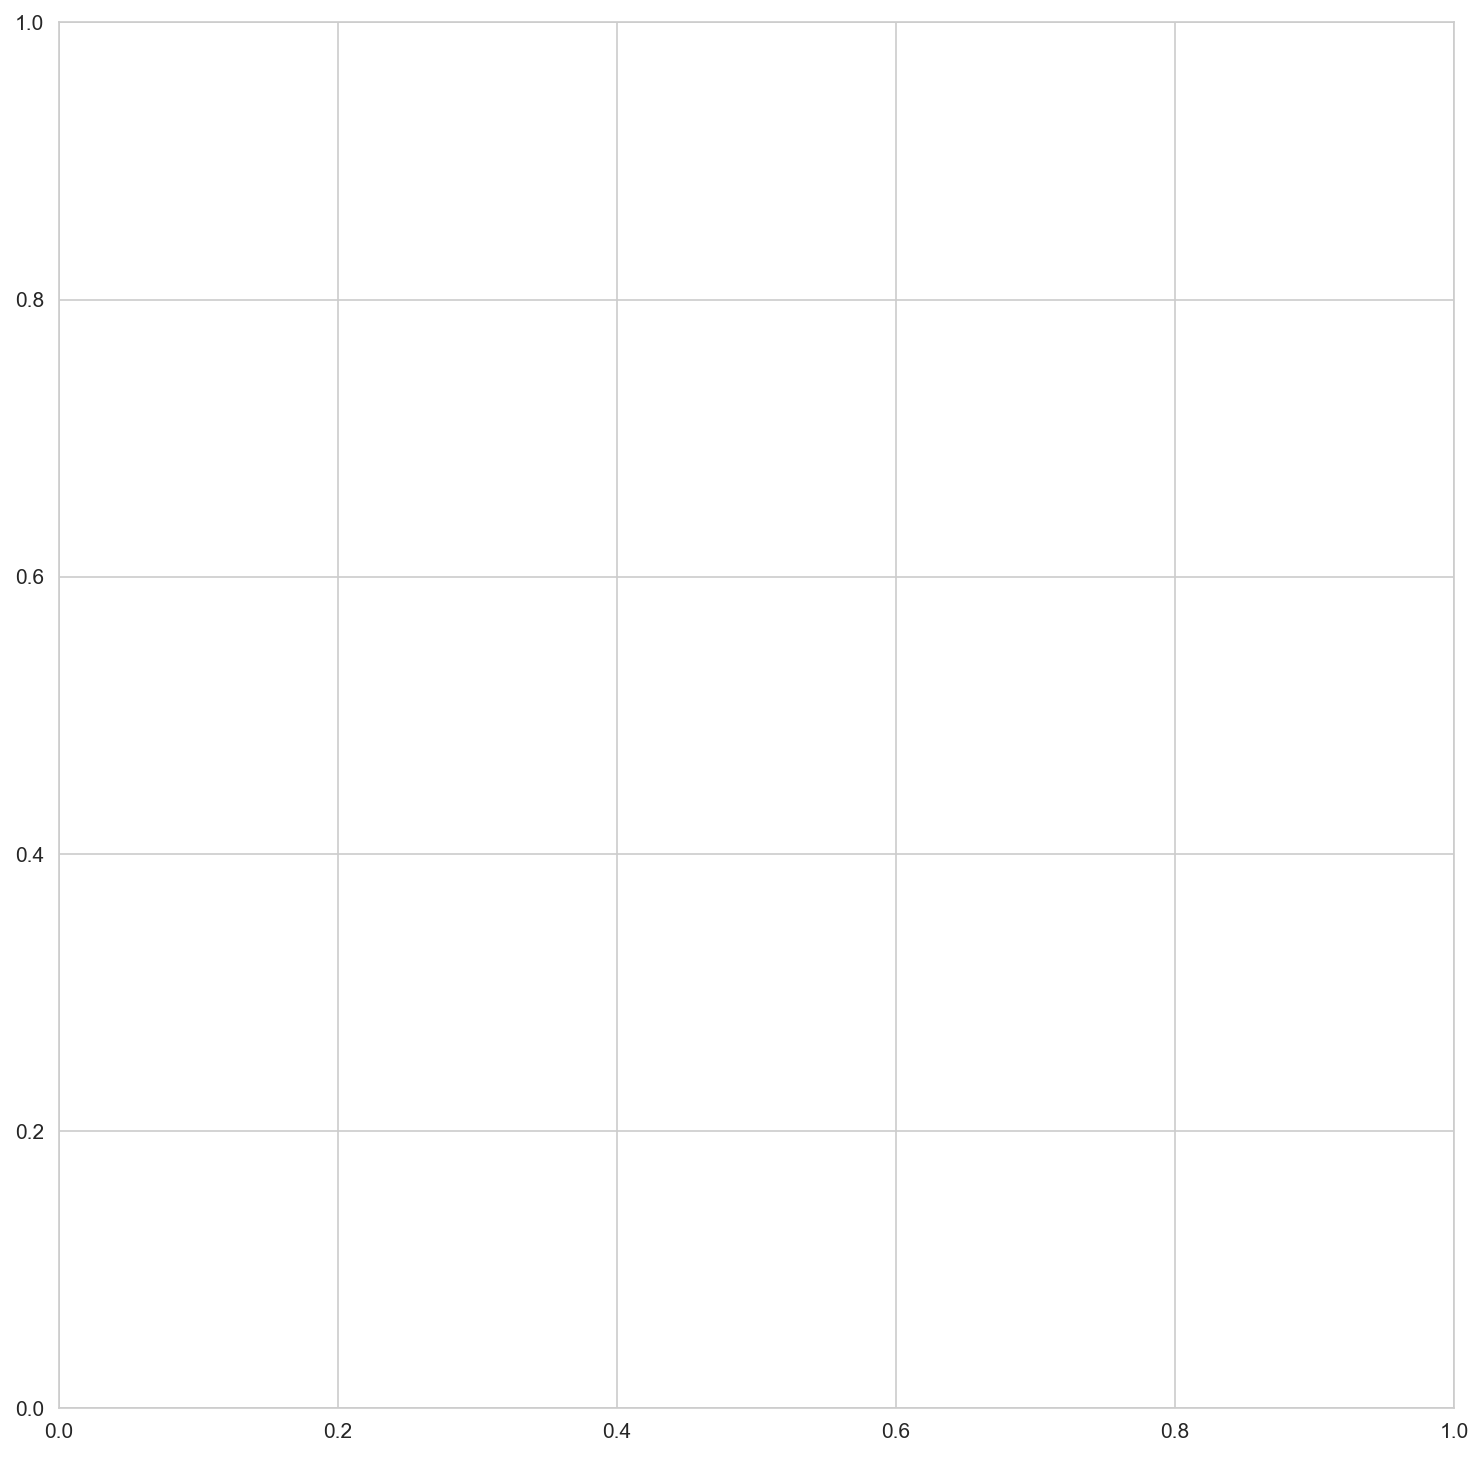

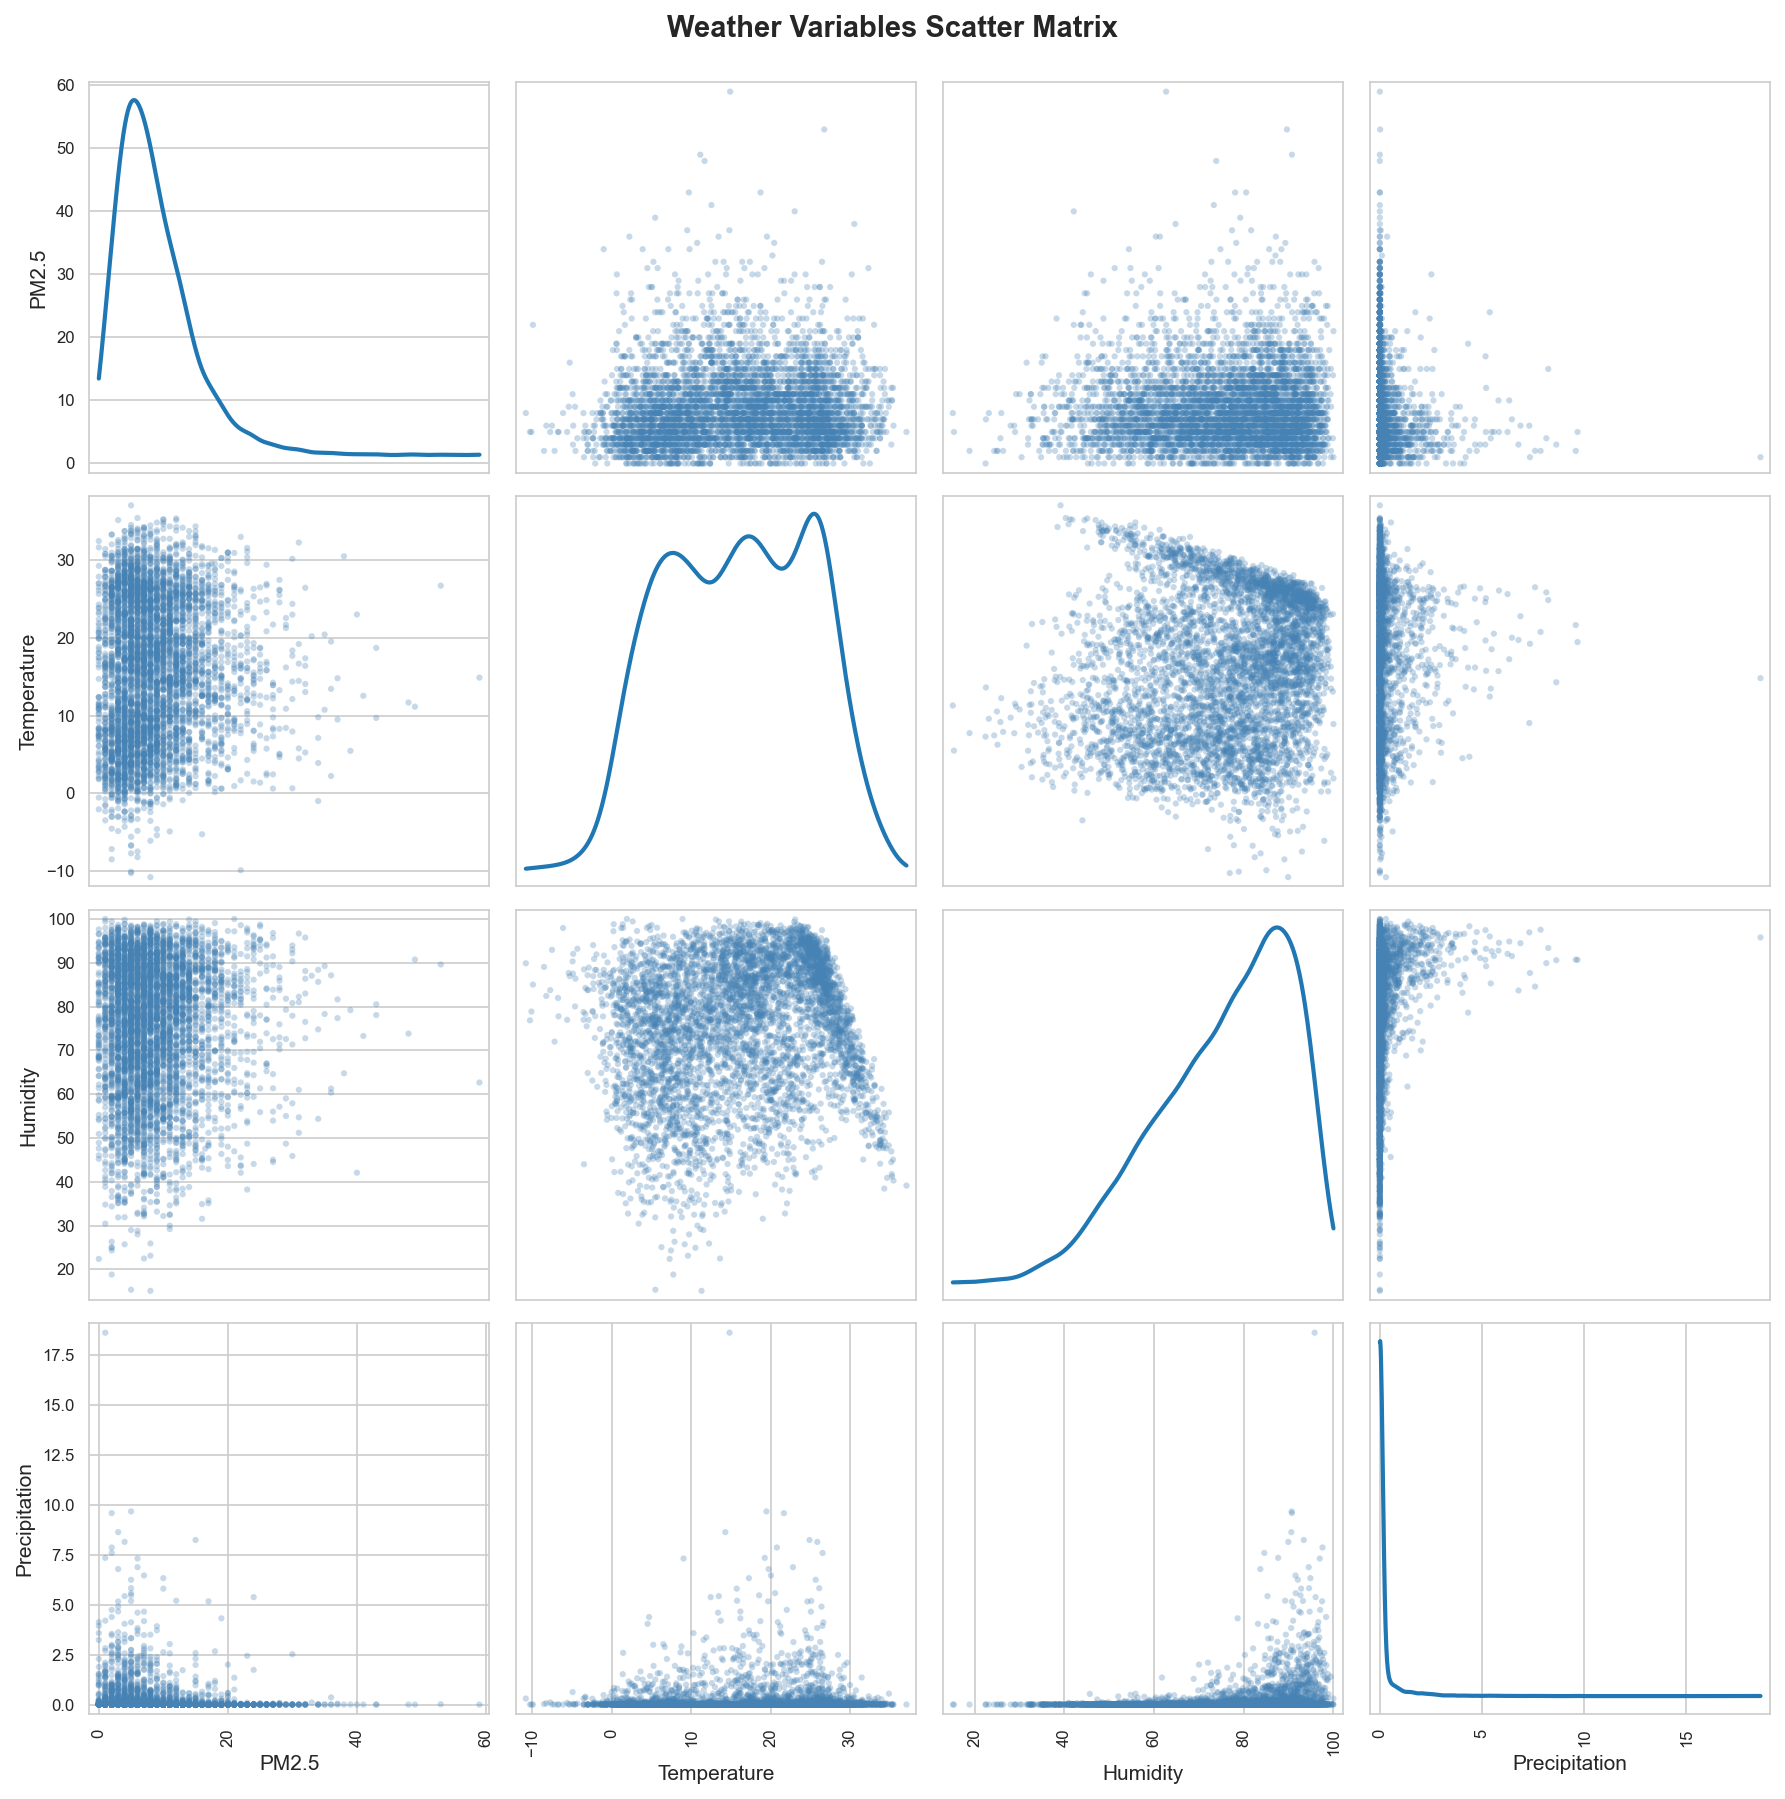

In [14]:
from pandas.plotting import scatter_matrix

fig, axes = plt.subplots(figsize=(12, 12))

weather_sample = df[['pm25_ugm3_mean', 'temperature_c_mean', 'humidity_pct_mean', 
                     'precipitation_mm_mean']].dropna().sample(n=min(5000, len(df)), random_state=42)
weather_sample.columns = ['PM2.5', 'Temperature', 'Humidity', 'Precipitation']

scatter_matrix(weather_sample, alpha=0.3, figsize=(12, 12), diagonal='kde',
              color='steelblue', density_kwds={'linewidth': 2})

plt.suptitle('Weather Variables Scatter Matrix', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('graphs/weather/12_scatter_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: graphs/weather/12_scatter_matrix.png")
plt.show()

## Summary - All Weather Relationship Graphs Generated

In [15]:
print("="*70)
print("PM2.5 AND WEATHER RELATIONSHIP GRAPHS GENERATED")
print("="*70)

print("\n🌡️ TEMPERATURE RELATIONSHIPS:")
print("  ✓ 01_pm25_vs_temperature_scatter.png")
print("  ✓ 02_pm25_vs_temp_seasonal.png")
print("  ✓ 07_pm25_temp_monthly_trends.png")

print("\n💧 HUMIDITY RELATIONSHIPS:")
print("  ✓ 03_pm25_vs_humidity_scatter.png")
print("  ✓ 08_pm25_humidity_hourly.png")

print("\n☁️ CLOUD & SOLAR:")
print("  ✓ 04_pm25_vs_cloud_cover.png")
print("  ✓ 09_pm25_vs_solar_radiation.png")

print("\n🌧️ PRECIPITATION:")
print("  ✓ 05_pm25_vs_precipitation.png")

print("\n📊 COMPREHENSIVE ANALYSES:")
print("  ✓ 06_weather_correlation_matrix.png")
print("  ✓ 10_pm25_by_weather_conditions.png")
print("  ✓ 11_timeseries_pm25_temp_humid.png")
print("  ✓ 12_scatter_matrix.png")

# Calculate and display correlations
weather_vars = ['pm25_ugm3_mean', 'temperature_c_mean', 'humidity_pct_mean', 
               'precipitation_mm_mean', 'cloud_cover_pct_mean']
corr_with_pm25 = df[weather_vars].corr()['pm25_ugm3_mean'].drop('pm25_ugm3_mean')

print("\n📈 KEY CORRELATIONS WITH PM2.5:")
for var, corr in corr_with_pm25.items():
    var_name = var.replace('_mean', '').replace('_', ' ').title()
    print(f"  • {var_name}: r = {corr:.3f}")

print("\n" + "="*70)
print("All 12 PM2.5-weather relationship graphs saved to graphs/weather/")
print("Each graph can be used independently in your presentation")
print("="*70)

PM2.5 AND WEATHER RELATIONSHIP GRAPHS GENERATED

🌡️ TEMPERATURE RELATIONSHIPS:
  ✓ 01_pm25_vs_temperature_scatter.png
  ✓ 02_pm25_vs_temp_seasonal.png
  ✓ 07_pm25_temp_monthly_trends.png

💧 HUMIDITY RELATIONSHIPS:
  ✓ 03_pm25_vs_humidity_scatter.png
  ✓ 08_pm25_humidity_hourly.png

☁️ CLOUD & SOLAR:
  ✓ 04_pm25_vs_cloud_cover.png
  ✓ 09_pm25_vs_solar_radiation.png

🌧️ PRECIPITATION:
  ✓ 05_pm25_vs_precipitation.png

📊 COMPREHENSIVE ANALYSES:
  ✓ 06_weather_correlation_matrix.png
  ✓ 10_pm25_by_weather_conditions.png
  ✓ 11_timeseries_pm25_temp_humid.png
  ✓ 12_scatter_matrix.png



📈 KEY CORRELATIONS WITH PM2.5:
  • Temperature C: r = 0.056
  • Humidity Pct: r = 0.027
  • Precipitation Mm: r = -0.096
  • Cloud Cover Pct: r = -0.061

All 12 PM2.5-weather relationship graphs saved to graphs/weather/
Each graph can be used independently in your presentation
